In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import textdescriptives as td
import re
import nltk

from collections import Counter
from datasets import load_dataset
from nltk.corpus import stopwords
from tqdm import trange
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords", quiet=True)

/Users/adisontan/quorum/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
pd.set_option("display.max_columns", None)   # show every column
pd.set_option("display.max_colwidth", 80)    # cut long text so tables stay readable

def peek(name, df, n=5):
    print(f"{name}: {len(df):,} rows, {df.shape[1]} columns")
    print(df.head(n))

In [22]:
ds_50pct = load_dataset("takala/financial_phrasebank", "sentences_50agree")
ds_75pct = load_dataset("takala/financial_phrasebank", "sentences_75agree")
ds_100pct = load_dataset("takala/financial_phrasebank", "sentences_allagree")

print(ds_50pct)
print(ds_75pct)
print(ds_100pct)

/Users/adisontan/quorum/venv/lib/python3.12/site-packages/datasets/load.py:1486: FutureWarning: The repository for takala/financial_phrasebank contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/takala/financial_phrasebank
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 4846
    })
})
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3453
    })
})
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})


In [46]:
# peek financialphrasebank dataset
# create text labels from numerical labels

LABELS = {0: "negative", 1: "neutral", 2: "positive"}
ORDER = ["negative", "neutral", "positive"]
PALETTE = {"negative": "#e34948", "neutral": "#b9b8b2", "positive": "#2a78d6"}

df_50pct = pd.DataFrame(ds_50pct["train"])
df_50pct["label_name"] = df_50pct["label"].map(LABELS)

peek("takala/financial_phrasebank", df_50pct)

takala/financial_phrasebank: 4,846 rows, 3 columns
                                                                                                                                                                                                                               sentence  \
0                                                                                                       According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1                                        Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2  The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3        

In [62]:
# retrieve duplicate sentence

dupes = df_50pct[df_50pct.duplicated("sentence", keep=False)]
print(f"{df_50pct['sentence'].duplicated().sum()} duplicate rows ({dupes['sentence'].nunique()} sentences appear more than once)")

conflicts = dupes.groupby("sentence")["label"].nunique()
conflicts = conflicts[conflicts > 1]
print(f"{len(conflicts)} duplicated sentences have conflicting labels\n")

print(dupes.sort_values("sentence")[["sentence", "label_name"]])
print(dupes[dupes["sentence"].isin(conflicts.index)].sort_values("sentence")[["sentence", "label_name"]])

8 duplicate rows (8 sentences appear more than once)
2 duplicated sentences have conflicting labels

                                                                                                                                                                                                                                                                                                      sentence  \
2395                                                                                                                                                                                                                                                  Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .   
2396                                                                                                                                                                                                                                                  Ahlstrom 's share is quoted on the NASDAQ

In [61]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print(df_50pct.iloc[[0, 2, 3]][["sentence", "label_name"]])

                                                                                                                                                                                                                               sentence  \
0                                                                                                       According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
2  The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3                        With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .   

  label_name  
0    neutral  
2   negative  
3   positive  

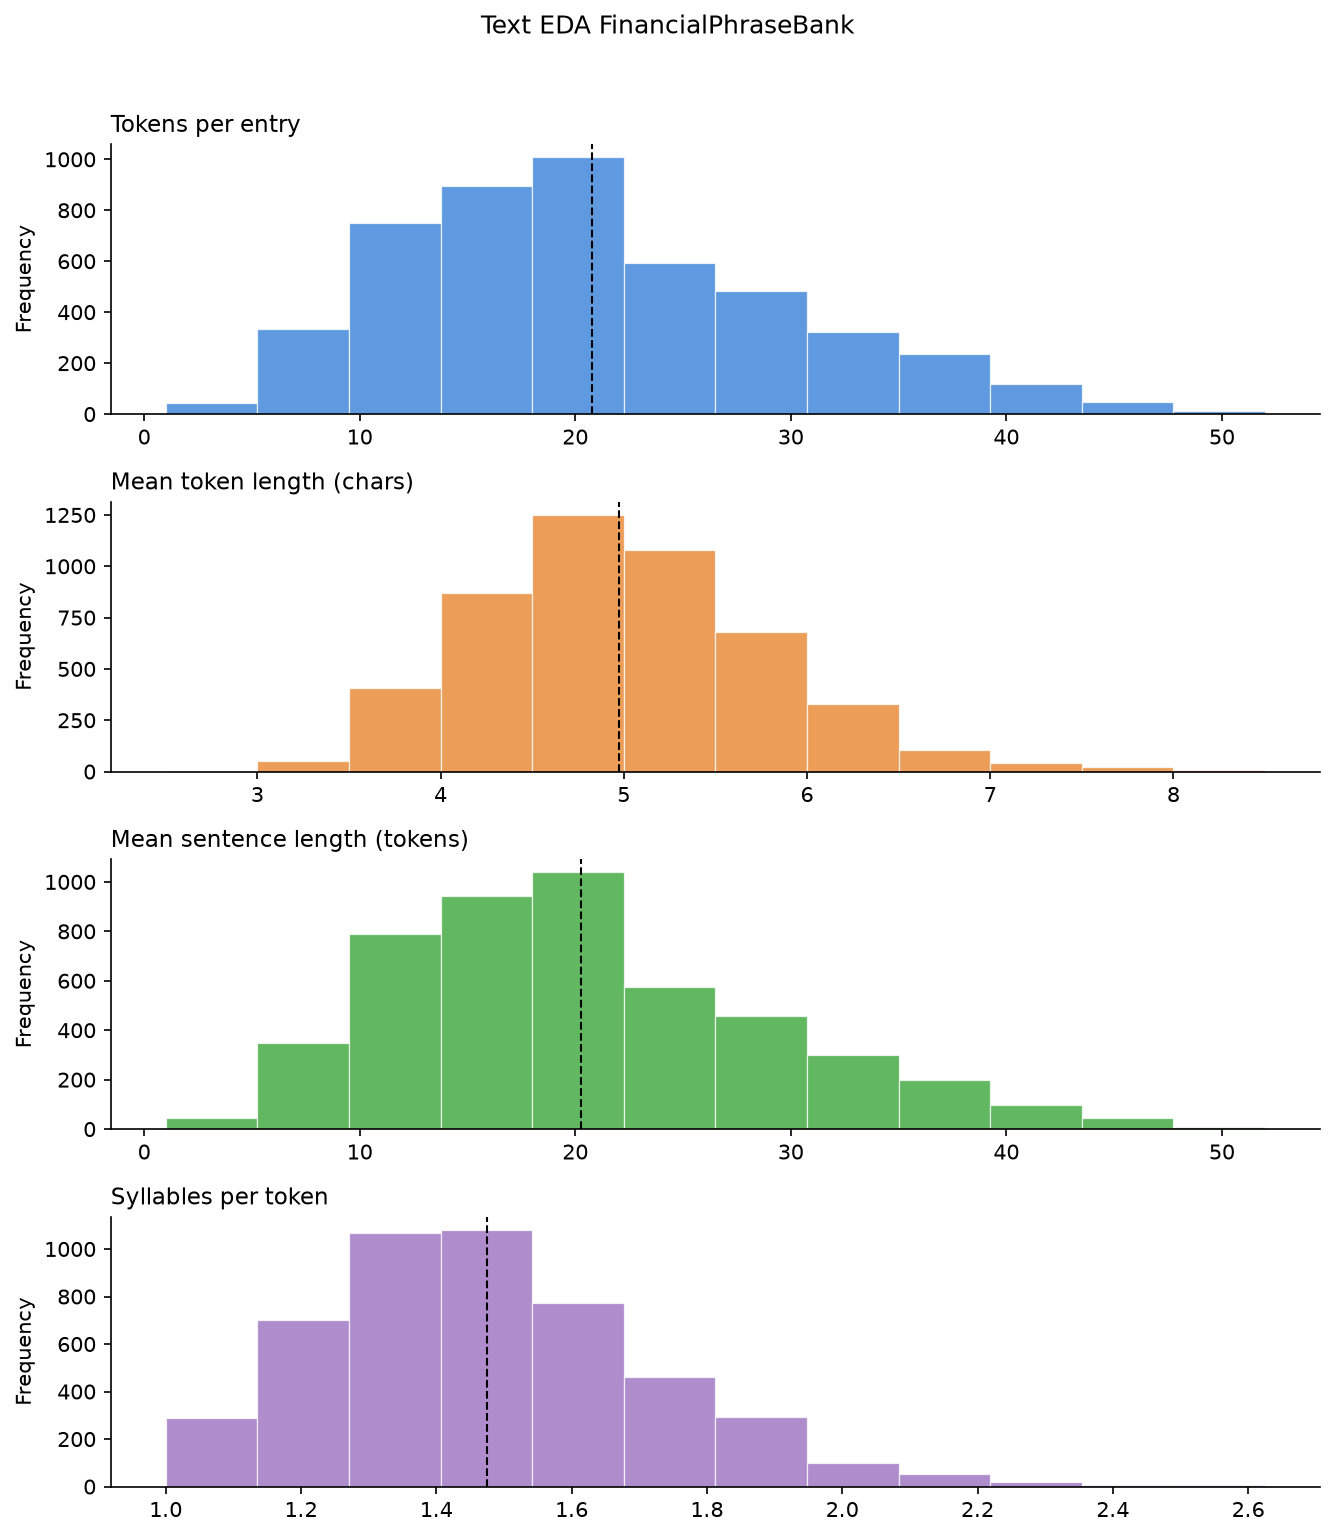

In [10]:
# text characteristics for gold dataset

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textdescriptives/descriptive_stats")

docs = list(nlp.pipe(df_50pct["sentence"]))

text_metrics_gold = td.extract_df(
    docs,
    metrics=["descriptive_stats"]
)

METRICS = [
    "n_tokens",
    "token_length_mean",
    "sentence_length_mean",
    "syllables_per_token_mean"
]

TITLES = {
    "n_tokens": "Tokens per entry",
    "token_length_mean": "Mean token length (chars)",
    "sentence_length_mean": "Mean sentence length (tokens)",
    "syllables_per_token_mean": "Syllables per token"
}

COLORS = ["#2a78d6", "#e67e22", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(4, 1, figsize=(9, 10), dpi=150)

fig.suptitle(
    "Text EDA FinancialPhraseBank",
    y=1.02
)

for ax, m, color in zip(axes, METRICS, COLORS):
    vals = text_metrics_gold[m].dropna()

    ax.hist(
        vals,
        bins=12,
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6
    )

    # Mean
    ax.axvline(
        vals.mean(),
        color="black",
        linewidth=1,
        linestyle="--"
    )

    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.set_ylabel("Frequency")
    
    # Clean up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
# perform data cleaning for term frequency visualization

STOPWORDS = set(stopwords.words("english"))

def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9.\- ]", "", text) 
    text = re.sub(r"\.(?!\d)", "", text)         # drop dots unless part of a number
    return " ".join(w for w in text.split() if w not in STOPWORDS)

df_wordfreq = df_50pct.copy()
df_wordfreq['strip_sentence'] = df_50pct['sentence'].apply(clean)
print(df_wordfreq)

                                                                                                                                                                                                                                  sentence  \
0                                                                                                          According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1                                           Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2     The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3                           With the new product

In [64]:
# splits each sentence into list of words

def corpus(text):
    text_list = text.split()
    return text_list

df_wordfreq['strip_sentence_list'] = df_wordfreq['strip_sentence'].apply(corpus)
print(df_wordfreq)

                                                                                                                                                                                                                                  sentence  \
0                                                                                                          According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1                                           Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2     The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .   
3                           With the new product

In [65]:
# compile word list

corpus = []
for i in trange(df_wordfreq.shape[0], ncols=150, nrows=10, colour='green', smoothing=0.8):
    corpus += df_wordfreq['strip_sentence_list'][i]
    
print(f'Corpus Length: {len(corpus)}\n')

mostCommon = Counter(corpus).most_common(10)
print(mostCommon)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 4846/4846 [00:00<00:00, 22824.26it/s]

Corpus Length: 64341

[('eur', 1015), ('company', 848), ('said', 544), ('mn', 515), ('finnish', 512), ('sales', 453), ('million', 440), ('net', 412), ('profit', 409), ('finland', 337)]


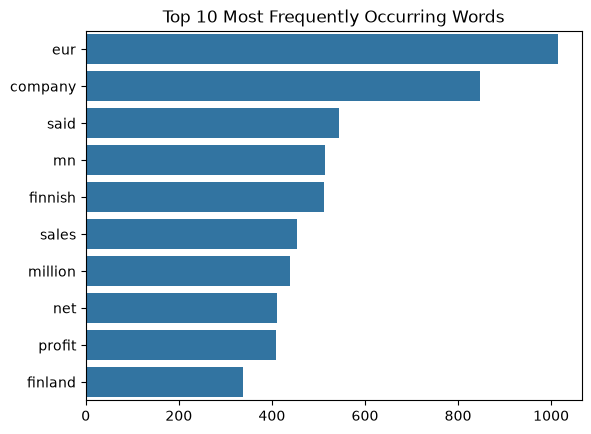

In [66]:
# visualise the top 10 uni-grams

words = []
freq = []
for word, count in mostCommon:
    words.append(word)
    freq.append(count)

sns.barplot(x=freq, y=words)
plt.title('Top 10 Most Frequently Occurring Words')
plt.show()

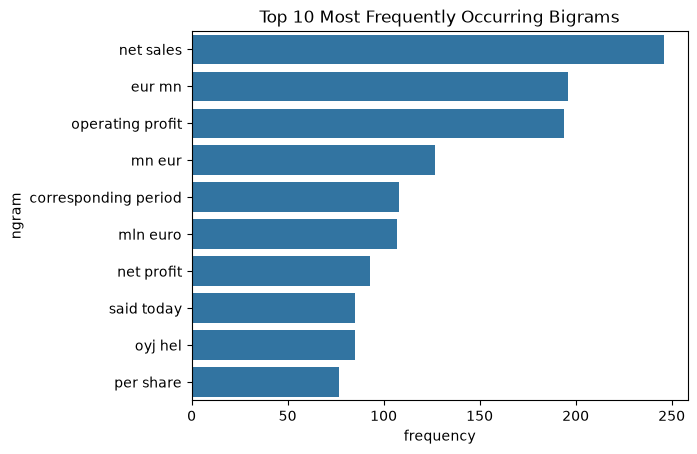

In [67]:
# bigram count

cv = CountVectorizer(ngram_range=(2,2))
bigrams = cv.fit_transform(df_wordfreq['strip_sentence'])

count_values = bigrams.toarray().sum(axis=0)
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occurring Bigrams')
plt.show()

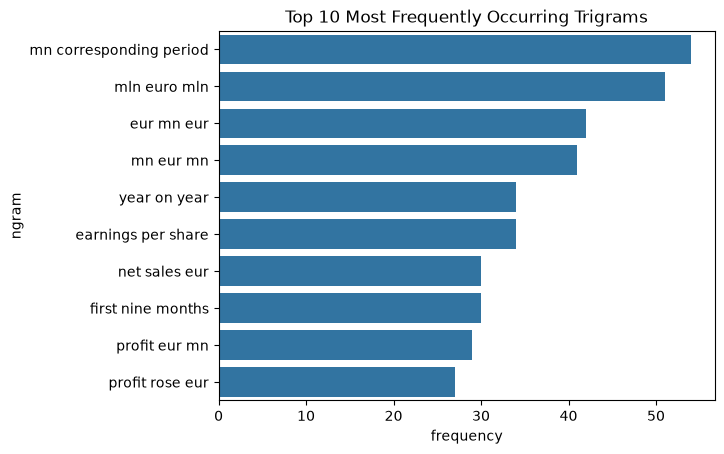

In [68]:
# trigram count

cv1 = CountVectorizer(ngram_range=(3,3))
trigrams = cv1.fit_transform(df_wordfreq['strip_sentence'])
count_values = trigrams.toarray().sum(axis=0)
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv1.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occurring Trigrams')
plt.show()

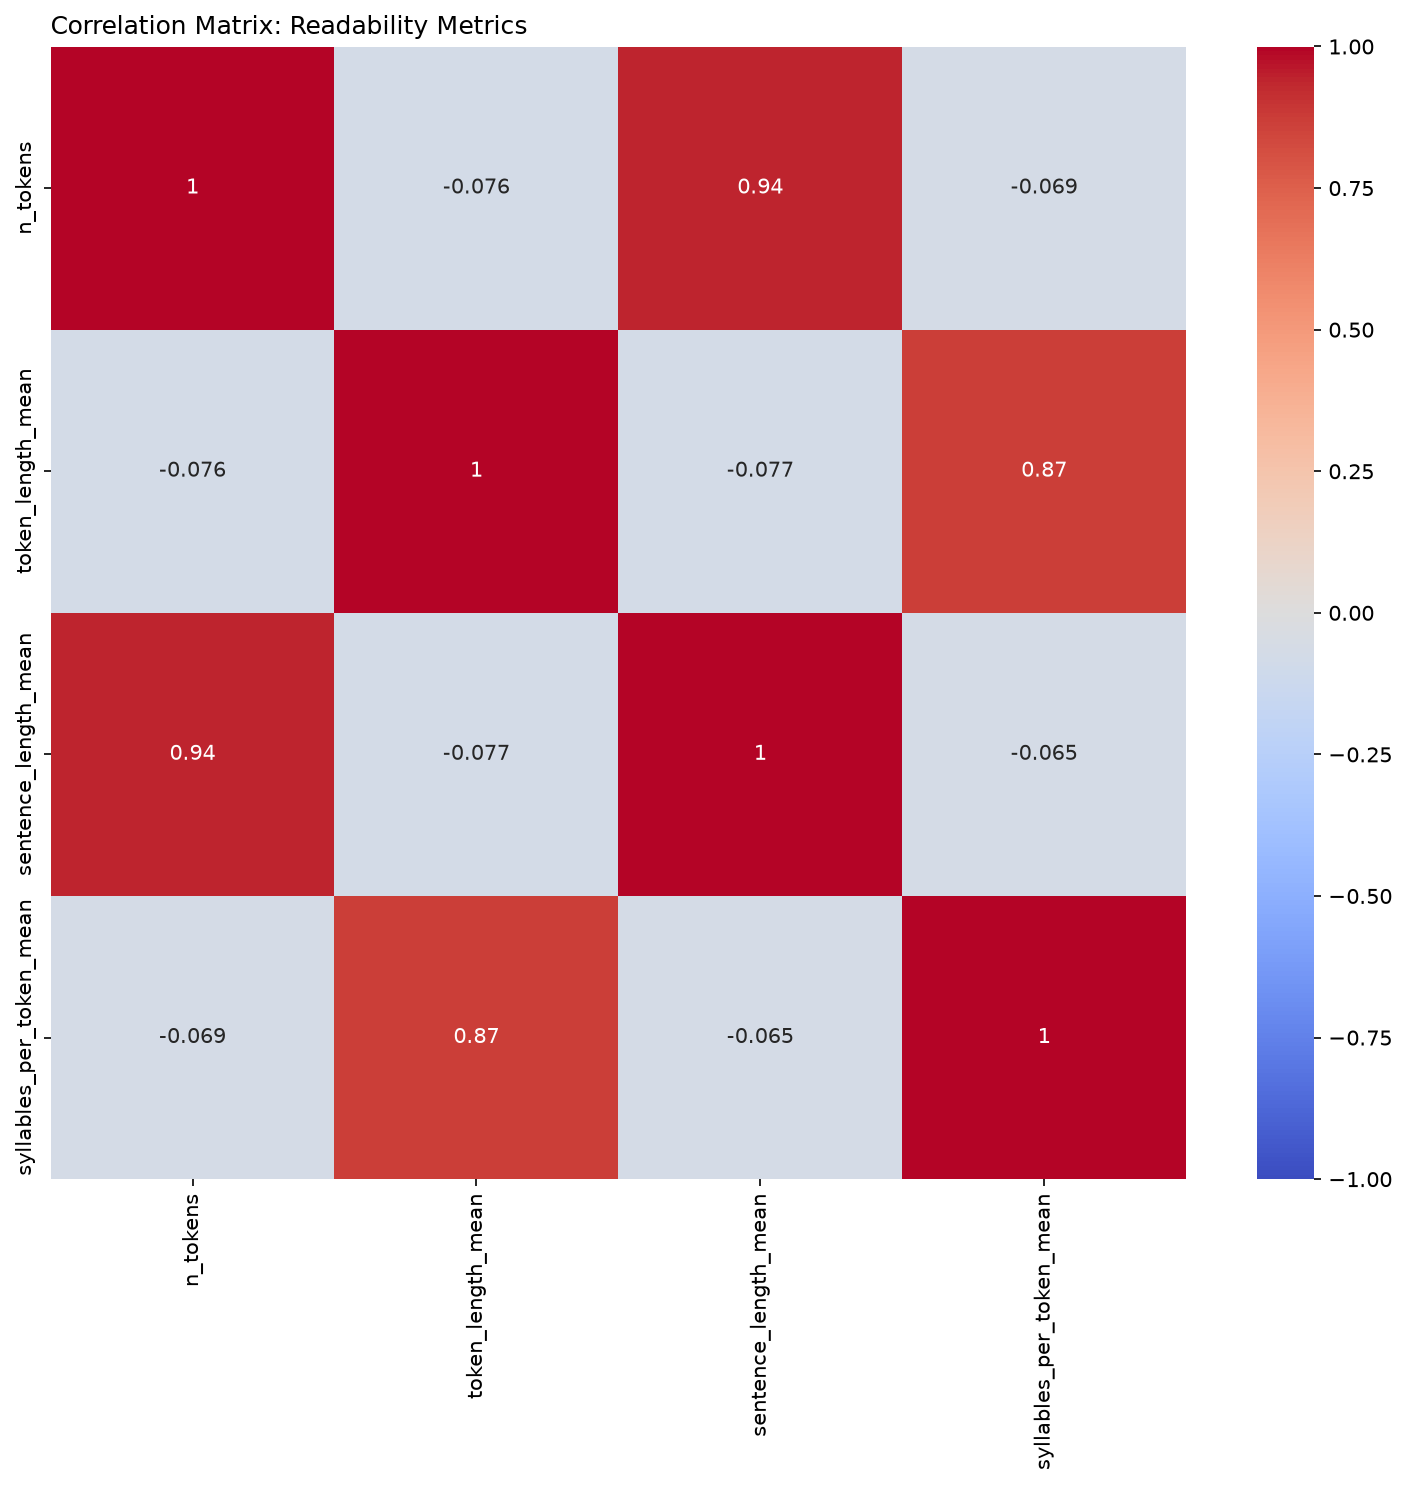

In [17]:
# correlation between text metrics

df_univar = text_metrics_gold.copy()
df_univar["label"] = df_50pct["label"].values
METRICS = ["n_tokens", "token_length_mean", "sentence_length_mean", "syllables_per_token_mean"]
corr = df_univar[METRICS].corr()

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix: Readability Metrics", loc="left")
plt.tight_layout()
plt.show()

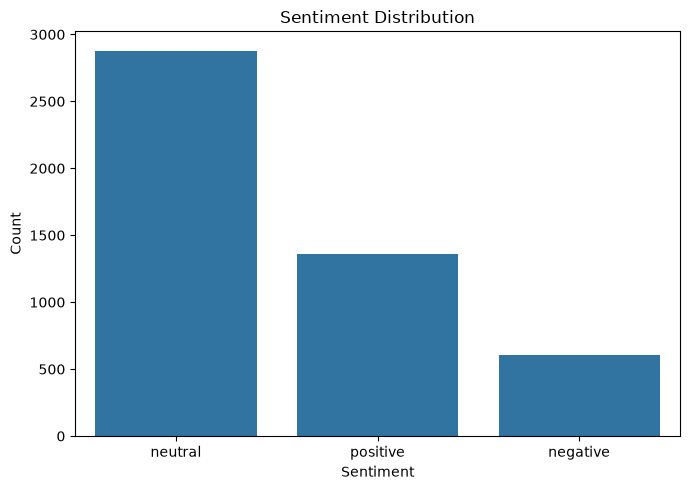

label_name
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [71]:
# dataset label sentiment distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_50pct,
    x="label_name",
    order=df_50pct["label_name"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df_50pct['label_name'].value_counts())

In [72]:
# build df_multivar from the computed metrics + label from df_50pct

df_multivar = text_metrics_gold.copy()
df_multivar["label"] = df_50pct["label_name"].values

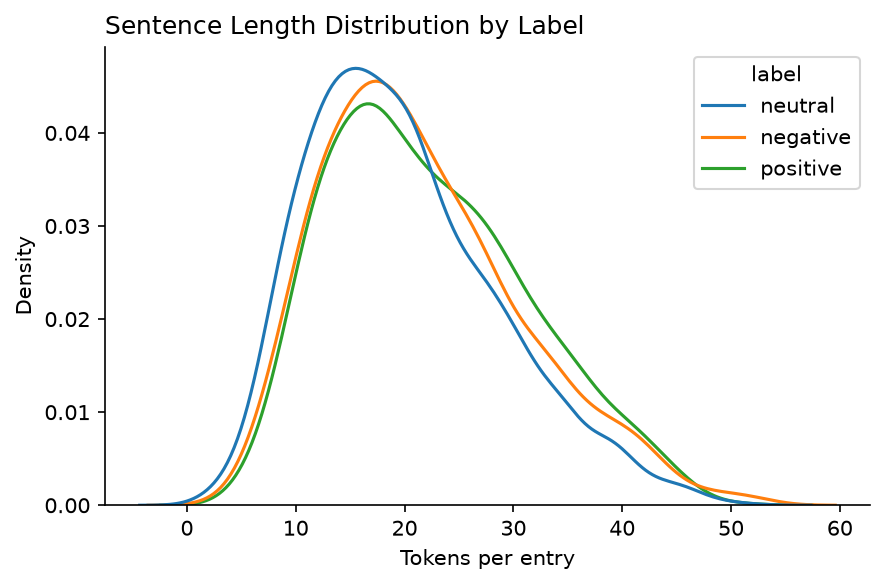

In [73]:
# sentence length distribution by labels

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
sns.kdeplot(data=df_multivar, x="n_tokens", hue="label", common_norm=False, ax=ax)
ax.set_title("Sentence Length Distribution by Label", loc="left")
ax.set_xlabel("Tokens per entry")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

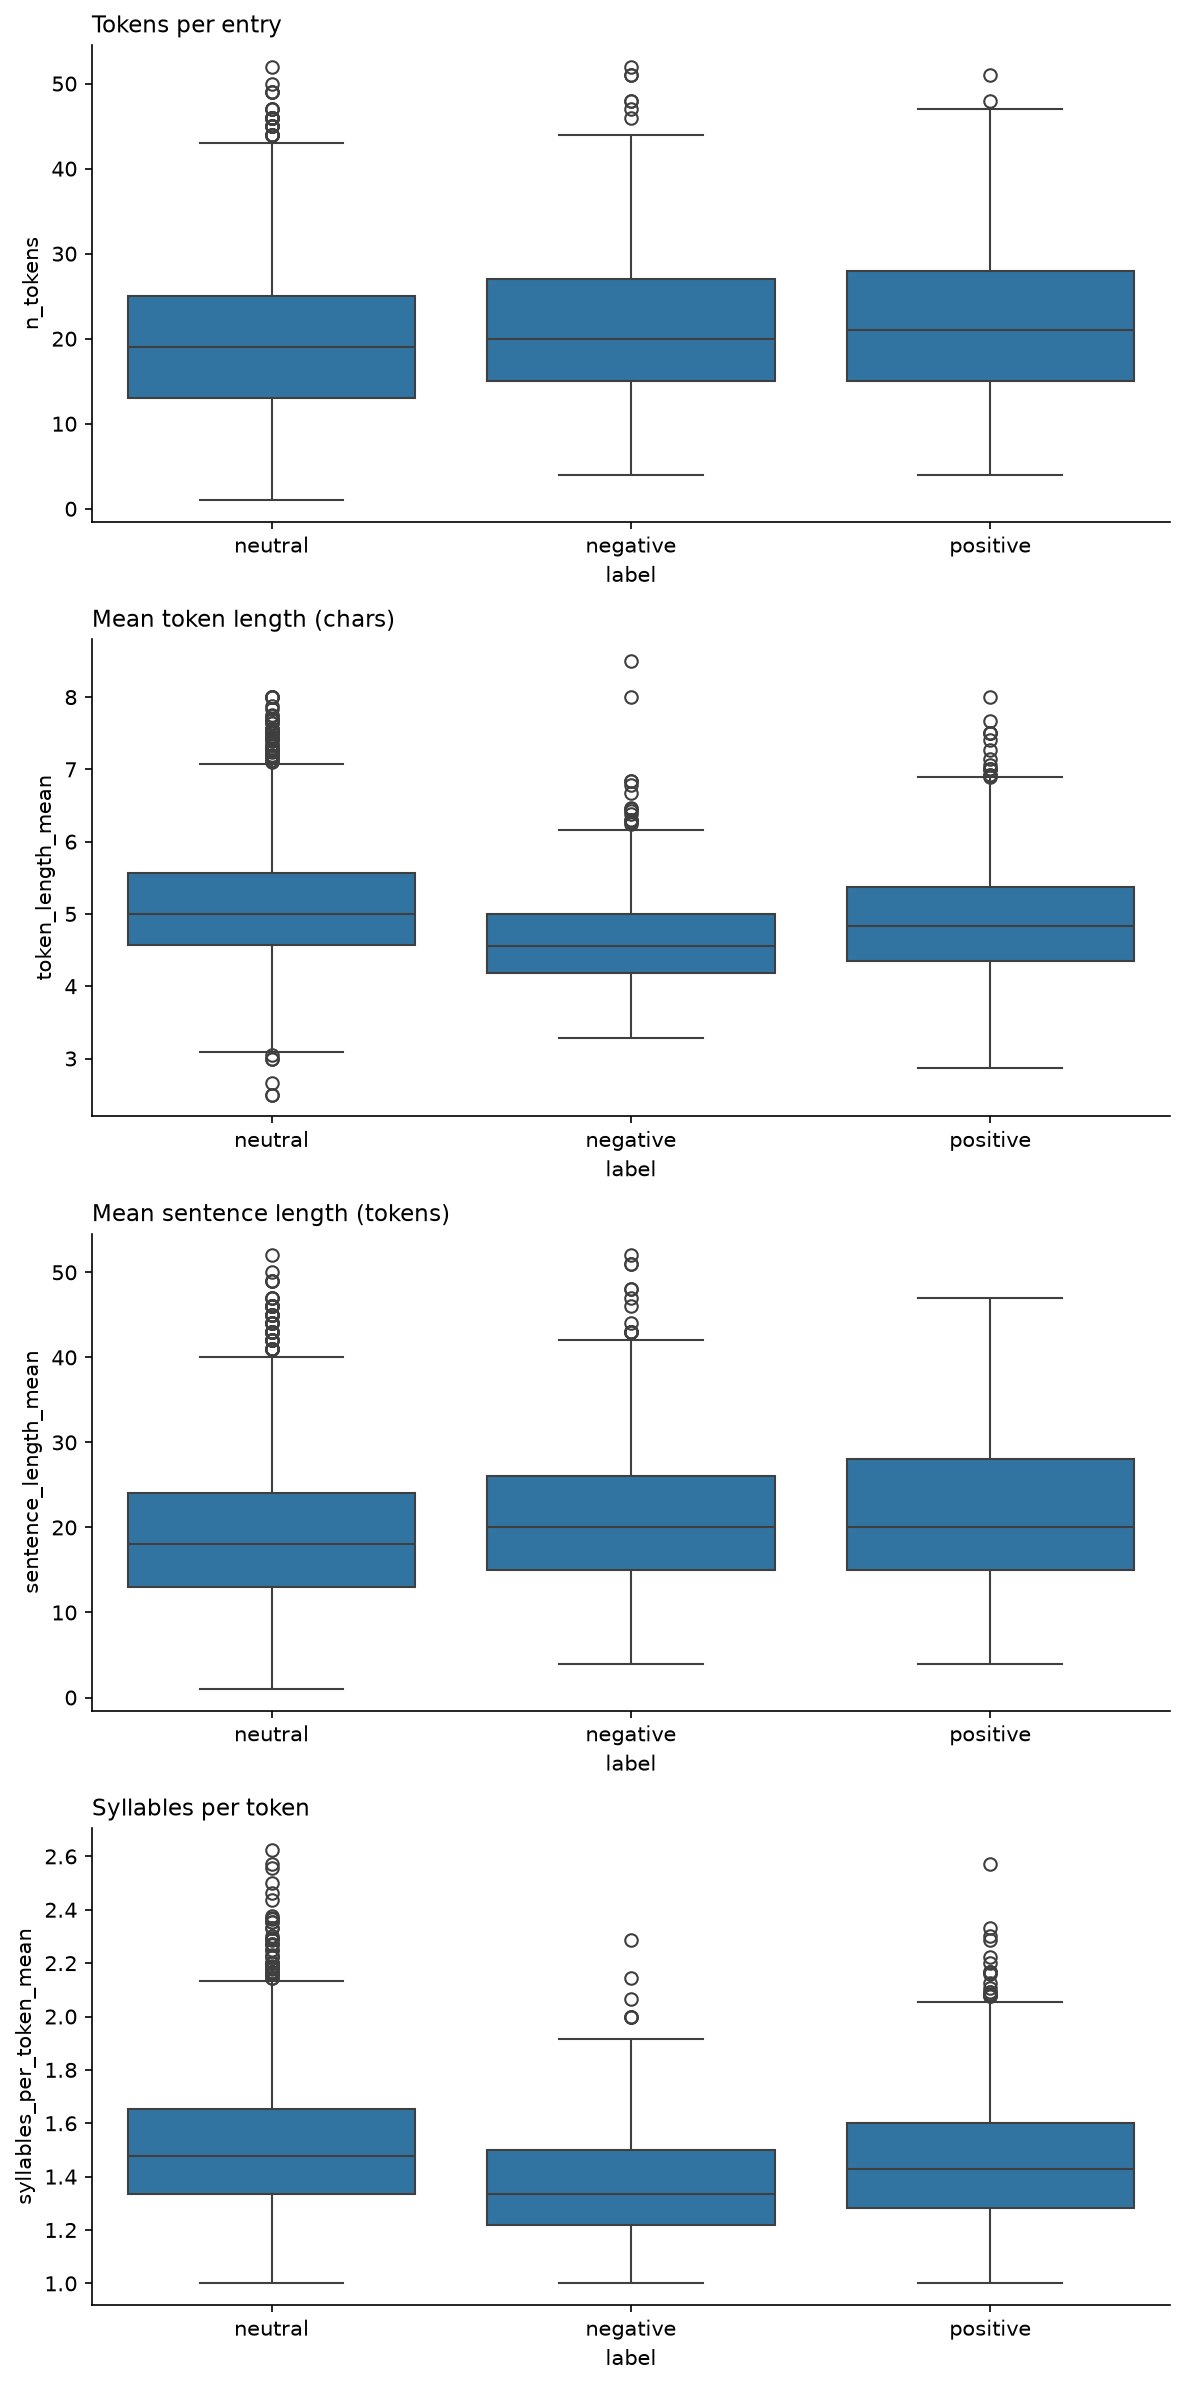

In [74]:
# text information vs labels

fig, axes = plt.subplots(4, 1, figsize=(8, 16), dpi=150)
for ax, m in zip(axes, METRICS):
    sns.boxplot(data=df_multivar, x="label", y=m, ax=ax)
    ax.set_title(TITLES[m], fontsize=11, loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [75]:
# view keyword (up/down) trends against sentiment

UP = r"\b(?:rose|rise|rises|risen|increase|increased|increases|grew|grow|grows|higher|improved|improve|gained|gain)\b"
DOWN = r"\b(?:fell|fall|falls|fallen|decrease|decreased|decreases|declined|decline|declines|lower|dropped|drop|drops|narrowed)\b"

text = df_50pct["sentence"].str.lower()
up, down = text.str.contains(UP), text.str.contains(DOWN)

df_50pct["direction"] = "none"
df_50pct.loc[up & ~down, "direction"] = "up"
df_50pct.loc[down & ~up, "direction"] = "down"
df_50pct.loc[up & down, "direction"] = "both"
print(pd.crosstab(df_50pct["direction"], df_50pct["label_name"]))

reversals = df_50pct[((df_50pct["direction"] == "down") & (df_50pct["label_name"] == "positive")) |
                     ((df_50pct["direction"] == "up") & (df_50pct["label_name"] == "negative"))]
print(f"\n{len(reversals)} sentences where the direction word contradicts the label\n")
print(reversals[["sentence", "label_name"]].head(10))

label_name  negative  neutral  positive
direction                              
both              17        8         6
down             166       27        25
none             414     2791       981
up                 7       53       351

32 sentences where the direction word contradicts the label

                                                                                                                                                                                                                                                              sentence  \
421                                                                                                                                   Compared with the FTSE 100 index , which rose 36.7 points ( or 0.6 % ) on the day , this was a relative price change of -0.2 % .   
423                                                                                                                                   Compared with the FTSE 100 index